In [35]:
import re 
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from pre_processing_utils import Utils

In [36]:
folder_path = Path.cwd().parent / "data/new" 

df = pd.DataFrame()
for subdir in folder_path.iterdir():
    if subdir.is_dir():
        if "new" not in subdir.name:
            print(f"Processing {subdir.name}...")
            df1 = pd.read_csv(subdir / "NestedGameNode.csv")
            df1["session"] = subdir.name
            
            df = pd.concat([df, df1], ignore_index=True)

def get_outer_proposal(definition):
    try:
        proposal = definition["summary"].get("outer_proposal", np.nan)
    except (KeyError, TypeError):
        proposal = np.nan
    return proposal

def get_inner_proposal(definition):
    try:
        proposal = definition["summary"].get("inner_proposal", np.nan)
        proposal = int(proposal)
    except (KeyError, TypeError):
        proposal = np.nan
    return proposal

def get_outer_acceptance(definition):
    try:
        acceptance = definition["summary"].get("outer_acceptance", np.nan)
    except (KeyError, TypeError):
        acceptance = np.nan
    return acceptance

def get_inner_acceptance(definition):
    try:
        acceptance = definition["summary"].get("inner_acceptance", np.nan)
    except (KeyError, TypeError):
        acceptance = np.nan
    return acceptance

def get_player1_accumulated_score(definition):
    try:
        scores = definition["summary"].get("accumulated_rewards", np.nan)
        keys = list(scores.keys())
        keys = [int(k) for k in keys]
        min_key = min(keys)
        return scores[str(min_key)]
    except (KeyError, TypeError):
        score = np.nan
    return score

def get_player2_accumulated_score(definition):
    try:
        scores = definition["summary"].get("accumulated_rewards", np.nan)
        keys = list(scores.keys())
        keys = [int(k) for k in keys]
        max_key = max(keys)
        return scores[str(max_key)]
    except (KeyError, TypeError):
        score = np.nan
    return score

df = Utils.parse_dicts_in_dataframe(df)
df["outer_proposal"] = df["definition"].apply(lambda x: get_outer_proposal(x))
df["inner_proposal"] = df["definition"].apply(lambda x: get_inner_proposal(x))
df["outer_acceptance"] = df["definition"].apply(lambda x: get_outer_acceptance(x))
df["inner_acceptance"] = df["definition"].apply(lambda x: get_inner_acceptance(x))   
df["player1_accumulated_score"] = df["definition"].apply(lambda x: get_player1_accumulated_score(x))
df["player2_accumulated_score"] = df["definition"].apply(lambda x: get_player2_accumulated_score(x))

df = Utils.add_time_steps_to_dataframe(df)


Processing 05-25-batch-1...


In [37]:
df['time_step'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26])

In [38]:
print(f"Number of batches: {df['session'].nunique()}")
df.head()

Number of batches: 1


,vars,id,creation_time,failed,failed_reason,time_of_death,type,network_id,participant_id,trial_maker_id,...,class,object_type,session,outer_proposal,inner_proposal,outer_acceptance,inner_acceptance,player1_accumulated_score,player2_accumulated_score,time_step
0,{},29,2026-05-26 00:20:20,False,NaN,NaN,TrialSource,14,2,nested_games_trial_maker,...,NestedGameNode,Node,05-25-batch-1,NaN,NaN,NaN,NaN,NaN,NaN,1
1,{},30,2026-05-26 00:21:16,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...",2026-05-26 00:25:35,NestedGameNode,14,2,nested_games_trial_maker,...,NestedGameNode,Node,05-25-batch-1,self,5.0,Accept,Accept,5.0,5.0,2
2,{},34,2026-05-26 00:22:04,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...",2026-05-26 00:25:35,NestedGameNode,14,2,nested_games_trial_maker,...,NestedGameNode,Node,05-25-batch-1,self,5.0,Accept,Accept,10.0,10.0,3
3,{},35,2026-05-26 00:22:48,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...",2026-05-26 00:25:35,NestedGameNode,14,2,nested_games_trial_maker,...,NestedGameNode,Node,05-25-batch-1,self,5.0,Accept,Accept,15.0,15.0,4
4,{},40,2026-05-26 00:23:30,False,NaN,NaN,TrialSource,19,6,nested_games_trial_maker,...,NestedGameNode,Node,05-25-batch-1,NaN,NaN,NaN,NaN,NaN,NaN,1


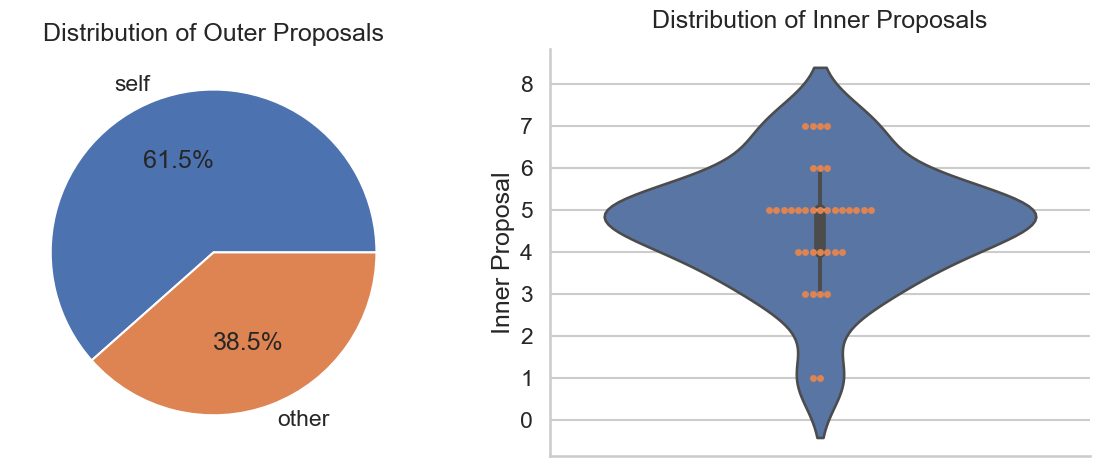

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Theme
sns.set_theme(style="whitegrid", context="talk")

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------
# Left: Pie chart
# -----------------------
proposal_counts = df["outer_proposal"].value_counts()

axes[0].pie(
    proposal_counts.values,
    labels=proposal_counts.index,
    autopct="%1.1f%%",
)

axes[0].set_title("Distribution of Outer Proposals")

# -----------------------
# Right: Violin plot
# -----------------------
sns.violinplot(
    y=df["inner_proposal"],
    ax=axes[1],
)
sns.swarmplot(
    y=df["inner_proposal"],
    ax=axes[1],
)

axes[1].set_ylabel("Inner Proposal")
axes[1].set_xlabel("")
axes[1].set_title("Distribution of Inner Proposals", pad=15)

# Integer ticks only
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

# Clean appearance
sns.despine(fig=fig)

# Layout
plt.tight_layout()

plt.show()

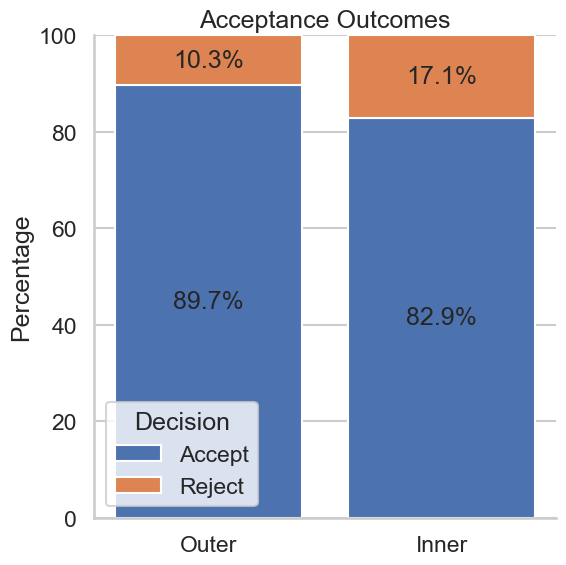

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="talk")

# Compute percentages
outer_counts = df["outer_acceptance"].value_counts(normalize=True) * 100
inner_counts = df["inner_acceptance"].value_counts(normalize=True) * 100

# Values
outer_accept = outer_counts.get("Accept", 0)
outer_reject = outer_counts.get("Reject", 0)

inner_accept = inner_counts.get("Accept", 0)
inner_reject = inner_counts.get("Reject", 0)

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

x = ["Outer", "Inner"]

# Accept portions
ax.bar(
    x,
    [outer_accept, inner_accept],
    label="Accept",
)

# Reject portions stacked on top
ax.bar(
    x,
    [outer_reject, inner_reject],
    bottom=[outer_accept, inner_accept],
    label="Reject",
)

# Percentage labels
for i, (acc, rej) in enumerate([
    (outer_accept, outer_reject),
    (inner_accept, inner_reject),
]):
    
    # Accept label
    ax.text(
        i,
        acc / 2,
        f"{acc:.1f}%",
        ha="center",
        va="center",
    )
    
    # Reject label
    ax.text(
        i,
        acc + rej / 2,
        f"{rej:.1f}%",
        ha="center",
        va="center",
    )

# Formatting
ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)
ax.set_title("Acceptance Outcomes")

ax.legend(title="Decision")

sns.despine()

plt.tight_layout()
plt.show()

In [41]:
last_scores = (
    df.sort_values("time_step")
      .groupby(["session", "network_id"])
      .agg(
          player1_accumulated_score=("player1_accumulated_score", "last"),
          player2_accumulated_score=("player2_accumulated_score", "last"),
          last_round=("time_step", "last"),
      )
      .reset_index()
)
last_scores.reset_index(drop=True, inplace=True)
last_scores

,session,network_id,player1_accumulated_score,player2_accumulated_score,last_round
0,05-25-batch-1,14,20.0,20.0,5
1,05-25-batch-1,19,25.0,25.0,7
2,05-25-batch-1,22,NaN,NaN,1
3,05-25-batch-1,27,16.0,14.0,4
4,05-25-batch-1,35,79.0,91.0,26
5,05-25-batch-1,39,0.0,0.0,2


In [42]:
last_scores['min/max'] = last_scores.apply(
    lambda row: min(row["player1_accumulated_score"], row["player2_accumulated_score"]) / max(row["player1_accumulated_score"], row["player2_accumulated_score"]) if max(row["player1_accumulated_score"], row["player2_accumulated_score"]) > 0 else np.nan,
    axis=1
)

last_scores['efficiency'] = last_scores.apply(
    lambda row: sum([row["player1_accumulated_score"], row["player2_accumulated_score"]]) / (10 * row["last_round"]) if row["last_round"] > 0 else np.nan,
    axis=1
)

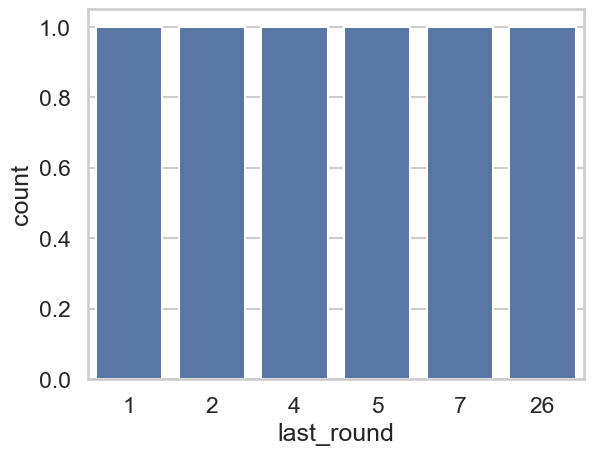

In [43]:
ax =sns.countplot(
    x=last_scores["last_round"],
)

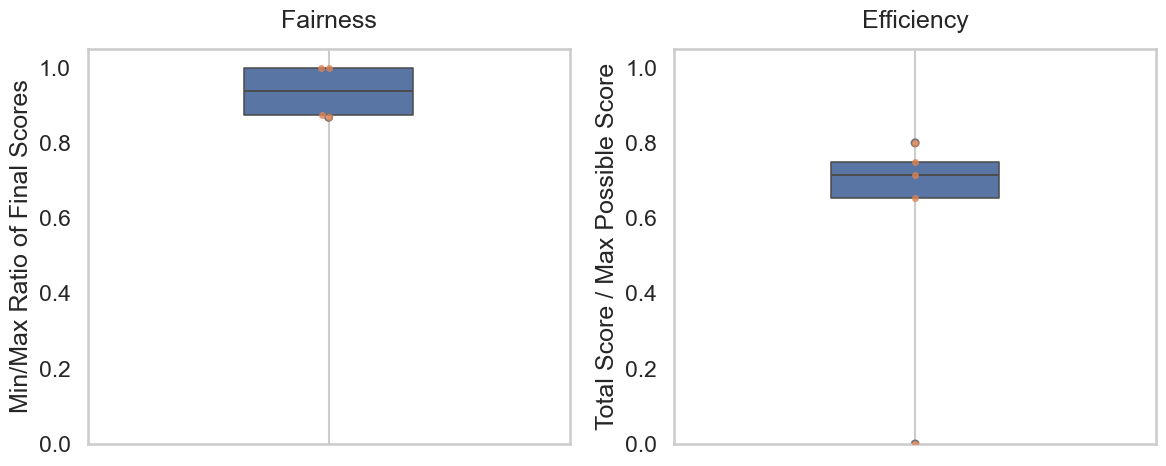

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Professional theme
# sns.set_theme(style="whitegrid", context="talk")

# Create figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Left: Fairness
# -------------------------
sns.boxenplot(
    y=last_scores["min/max"],
    ax=axes[0],
    width=0.35,
)

sns.swarmplot(
    y=last_scores["min/max"],
    ax=axes[0],
    size=5,
    alpha=0.8,
)

axes[0].set_ylabel("Min/Max Ratio of Final Scores")
axes[0].set_xlabel("")
axes[0].set_title("Fairness", pad=15)
axes[0].grid()
axes[0].set_ylim(0, 1.05)

# -------------------------
# Right: Efficiency
# -------------------------
sns.boxenplot(
    y=last_scores["efficiency"],
    ax=axes[1],
    width=0.35,
)

sns.swarmplot(
    y=last_scores["efficiency"],
    ax=axes[1],
    size=5,
    alpha=0.8,
)

axes[1].set_ylabel("Total Score / Max Possible Score")
axes[1].set_xlabel("")
axes[1].set_title("Efficiency", pad=15)
axes[1].grid()
axes[1].set_ylim(0, 1.05)

# Layout
plt.tight_layout()

plt.show()

In [45]:
def round_efficiency(row):
    proposal = row["inner_proposal"]
    acceptance = row["inner_acceptance"]
    if pd.isna(proposal) or pd.isna(acceptance):
        return 0
    elif acceptance == "Reject":
        return 0
    elif acceptance == "Accept":
        return 1

def round_fairness(row):
    proposal = row["inner_proposal"]
    acceptance = row["inner_acceptance"]
    if pd.isna(proposal) or pd.isna(acceptance):
        return np.nan
    elif acceptance == "Reject":
        return 1
    elif acceptance == "Accept":
        return min([proposal, 10 - proposal]) / max([proposal, 10 - proposal]) if max([proposal, 10 - proposal]) > 0 else np.nan


df['round_efficiency'] = df.apply(round_efficiency, axis=1)
df['round_fairness'] = df.apply(round_fairness, axis=1)

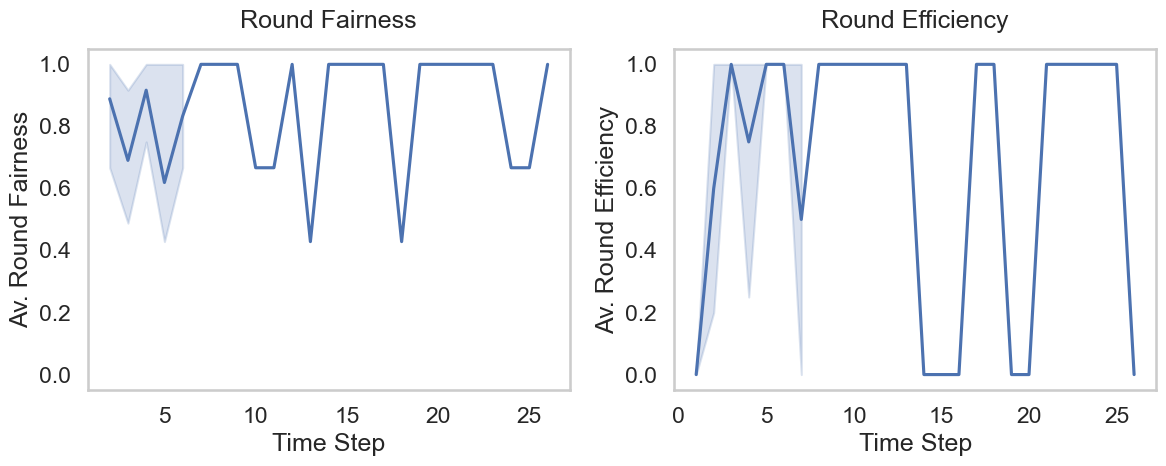

In [46]:
# Professional theme
sns.set_theme(style="whitegrid", context="talk")

# Create figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Left: Fairness
# -------------------------
sns.lineplot(
    x="time_step",
    y="round_fairness",
    ax=axes[0],
    data=df,
)
axes[0].set_ylabel("Av. Round Fairness")
axes[0].set_xlabel("Time Step")
axes[0].set_title("Round Fairness", pad=15)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid()

# -------------------------
# Right: Efficiency
# -------------------------
sns.lineplot(
    x="time_step",
    y="round_efficiency",
    ax=axes[1],
    data=df,
)
axes[1].set_ylabel("Av. Round Efficiency")
axes[1].set_xlabel("Time Step")
axes[1].set_title("Round Efficiency", pad=15)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid()

# Layout
plt.tight_layout()

plt.show()

In [47]:
def distance_to_perfect_fairness(row):
    if row['inner_proposal'] is not np.nan:
        return abs(row['inner_proposal'] - 5)
    return np.nan

df['distance_to_perfect_fairness'] = df.apply(distance_to_perfect_fairness, axis=1).shift(-1)

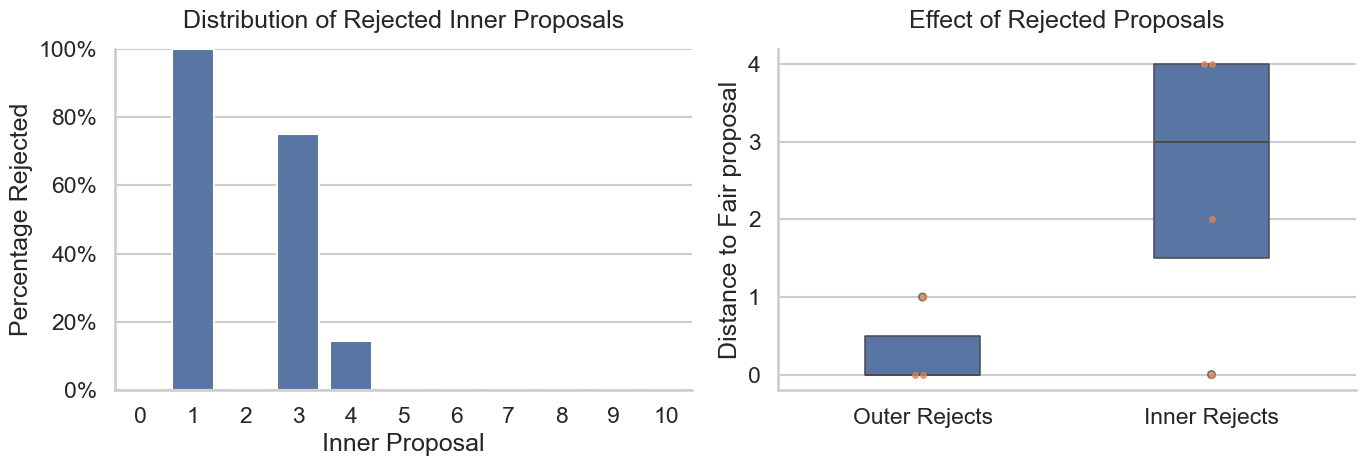

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import PercentFormatter, MaxNLocator

# Professional theme
sns.set_theme(style="whitegrid", context="talk")

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # -----------------------------------
# # Left plot:
# # Rejected inner proposals distribution
# # -----------------------------------
# sns.countplot(
#     data=df[df["inner_acceptance"] == "Reject"],
#     x="inner_proposal",
#     ax=axes[0],
# )
proposal_reject_rate = (
    df.groupby("inner_proposal")["inner_acceptance"]
      .apply(lambda s: (s == "Reject").mean())
      .reset_index(name="reject_percentage")
)
proposal_reject_rate = (
    proposal_reject_rate.set_index("inner_proposal")
      .reindex(range(11), fill_value=0)
      .reset_index()
)

sns.barplot(
    data=proposal_reject_rate,
    x="inner_proposal",
    y="reject_percentage",
    ax=axes[0],
)

# Integer x ticks
axes[0].set_xticks(range(11))
axes[0].set_xlabel("Inner Proposal")
axes[0].set_xticklabels(range(11))
axes[0].set_ylabel("Percentage Rejected")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

axes[0].set_title(
    "Distribution of Rejected Inner Proposals",
    pad=15,
)


# -----------------------------------
# Right plot:
# Distance to perfect fairness
# -----------------------------------
X_outer = df[df["outer_acceptance"] == "Reject"][
    "distance_to_perfect_fairness"
]

X_inner = df[df["inner_acceptance"] == "Reject"][
    "distance_to_perfect_fairness"
]

plot_df = pd.DataFrame({
    "Type": (
        ["Outer Rejects"] * len(X_outer)
        + ["Inner Rejects"] * len(X_inner)
    ),
    "Distance": list(X_outer) + list(X_inner),
})

sns.boxenplot(
    data=plot_df,
    x="Type",
    y="Distance",
    ax=axes[1],
    width=0.4,
)

sns.swarmplot(
    data=plot_df,
    x="Type",
    y="Distance",
    ax=axes[1],
    size=5,
    alpha=0.8,
)

axes[1].set_ylabel("Distance to Fair proposal")
axes[1].set_xlabel("")
axes[1].set_title(
    "Effect of Rejected Proposals",
    pad=15,
)

# Clean appearance
for ax in axes:
    sns.despine(ax=ax)

# Layout
plt.tight_layout()

plt.show()

In [58]:
df.columns

Index(['vars', 'id', 'creation_time', 'failed', 'failed_reason',
       'time_of_death', 'type', 'network_id', 'participant_id',
       'trial_maker_id', 'module_id', 'module_state_id', 'is_global',
       'on_deploy_complete', 'async_on_deploy_required',
       'async_on_deploy_requested', 'async_on_deploy_complete',
       'async_on_deploy_failed', 'key', 'degree', 'target_n_trials',
       'ready_to_spawn', 'child_id', 'parent_id', 'seed', 'definition',
       'context', 'participant_group', 'block', 'propagate_failure',
       'n_viable_trials', 'class', 'object_type', 'session', 'outer_proposal',
       'inner_proposal', 'outer_acceptance', 'inner_acceptance',
       'player1_accumulated_score', 'player2_accumulated_score', 'time_step',
       'round_efficiency', 'round_fairness', 'distance_to_perfect_fairness'],
      dtype='object')

In [61]:
columns = ["session", "network_id", "participant_id", "failed", "failed_reason", "definition", "time_step", "outer_proposal", "inner_proposal", "outer_acceptance", "inner_acceptance", "player1_accumulated_score", "player2_accumulated_score", "round_efficiency", "round_fairness", "distance_to_perfect_fairness"]
df1 = df[columns]
df1.head()

,session,network_id,participant_id,failed,failed_reason,definition,time_step,outer_proposal,inner_proposal,outer_acceptance,inner_acceptance,player1_accumulated_score,player2_accumulated_score,round_efficiency,round_fairness,distance_to_perfect_fairness
0,05-25-batch-1,14,2,False,NaN,"{'outer_game': 'ultimatum', 'inner_game': 'ult...",1,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.0
1,05-25-batch-1,14,2,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...","{'outer_game': 'ultimatum', 'inner_game': 'ult...",2,self,5.0,Accept,Accept,5.0,5.0,1,1.0,0.0
2,05-25-batch-1,14,2,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...","{'outer_game': 'ultimatum', 'inner_game': 'ult...",3,self,5.0,Accept,Accept,10.0,10.0,1,1.0,0.0
3,05-25-batch-1,14,2,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...","{'outer_game': 'ultimatum', 'inner_game': 'ult...",4,self,5.0,Accept,Accept,15.0,15.0,1,1.0,NaN
4,05-25-batch-1,19,6,False,NaN,"{'outer_game': 'ultimatum', 'inner_game': 'ult...",1,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.0


In [62]:
df1['participant_id'].value_counts()

participant_id
25    26
6      7
2      5
18     4
29     2
5      1
Name: count, dtype: int64